<a href="https://colab.research.google.com/github/Rohil121/bharat-portfolio-lab/blob/v0.3-robustness-testing/notebooks/03_robustness_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bharat Portfolio Lab — Robustness Testing

## Version v0.3

This notebook evaluates whether the Adaptive Barbell strategy remains reliable when the testing period, parameters and modelling assumptions change.

### Planned tests

- Development-period versus out-of-sample performance
- Momentum, volatility and trend-window sensitivity
- Transaction-cost stress testing
- Rolling return and risk analysis
- Market-regime performance
- Strategy robustness scoring

The objective is not to find the historically best parameter combination. The objective is to identify whether reasonable alternative assumptions produce broadly consistent results.

## 1. Environment Setup

This section prepares the Python environment for reproducible robustness testing of the Adaptive Barbell strategy.

In [1]:
%pip install -q yfinance

In [2]:
import sys
from importlib.metadata import version
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Display settings
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("v0.3 environment setup complete.")
print("-" * 45)
print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {version('matplotlib')}")
print(f"yfinance: {version('yfinance')}")
print(f"Random seed: {RANDOM_SEED}")

v0.3 environment setup complete.
---------------------------------------------
Python: 3.12.13
pandas: 2.2.2
NumPy: 2.0.2
Matplotlib: 3.10.0
yfinance: 0.2.66
Random seed: 42


## 2. Portfolio and Robustness-Test Configuration

The v0.3 analysis retains the same India 10 flagship portfolio so that the strategy remains comparable with version v0.2.

The historical period is divided into:

- **Development period:** used to examine and establish the strategy rules.
- **Out-of-sample period:** used to evaluate the frozen strategy on later data.

The out-of-sample results will receive greater importance than the full-period results.

In [3]:
# ---------------------------------------------------------
# India 10 Adaptive Barbell portfolio
# ---------------------------------------------------------

portfolio = pd.DataFrame(
    {
        "Company": [
            "HDFC Bank",
            "Tata Consultancy Services",
            "Hindustan Unilever",
            "Sun Pharmaceutical Industries",
            "Power Grid Corporation of India",
            "Bharti Airtel",
            "Larsen & Toubro",
            "Mahindra & Mahindra",
            "Bharat Electronics",
            "Trent",
        ],
        "Ticker": [
            "HDFCBANK.NS",
            "TCS.NS",
            "HINDUNILVR.NS",
            "SUNPHARMA.NS",
            "POWERGRID.NS",
            "BHARTIARTL.NS",
            "LT.NS",
            "M&M.NS",
            "BEL.NS",
            "TRENT.NS",
        ],
        "Sector": [
            "Financial Services",
            "Information Technology",
            "Consumer Staples",
            "Healthcare",
            "Utilities",
            "Telecommunication",
            "Industrials",
            "Automobile",
            "Defence Electronics",
            "Consumer Retail",
        ],
        "Strategy Bucket": [
            "Resilient Compounder",
            "Resilient Compounder",
            "Resilient Compounder",
            "Resilient Compounder",
            "Resilient Compounder",
            "Growth Leader",
            "Growth Leader",
            "Growth Leader",
            "Growth Leader",
            "Growth Leader",
        ],
    }
)

portfolio["Initial Weight"] = 1 / len(portfolio)

portfolio_tickers = portfolio["Ticker"].tolist()

resilient_tickers = portfolio.loc[
    portfolio["Strategy Bucket"] == "Resilient Compounder",
    "Ticker",
].tolist()

growth_tickers = portfolio.loc[
    portfolio["Strategy Bucket"] == "Growth Leader",
    "Ticker",
].tolist()


# ---------------------------------------------------------
# Market and portfolio assumptions
# ---------------------------------------------------------

BENCHMARK_TICKER = "^NSEI"
BENCHMARK_NAME = "Nifty 50"

INITIAL_CAPITAL = 1_000_000  # ₹10 lakh
TRADING_DAYS = 252
RISK_FREE_RATE = 0.065

TRANSACTION_COST_RATE = 0.0015


# ---------------------------------------------------------
# Historical testing periods
# ---------------------------------------------------------

DATA_START_DATE = "2016-01-01"

DEVELOPMENT_START_DATE = pd.Timestamp("2016-01-01")
OUT_OF_SAMPLE_START_DATE = pd.Timestamp("2022-01-01")

DOWNLOAD_END_DATE = (
    pd.Timestamp.today().normalize()
    + pd.Timedelta(days=1)
)


# ---------------------------------------------------------
# Frozen v0.2 strategy parameters
# ---------------------------------------------------------

BASE_MOMENTUM_LOOKBACK = 126
BASE_VOLATILITY_LOOKBACK = 63
BASE_TREND_LOOKBACK = 200

BASE_FULL_EQUITY_EXPOSURE = 1.00
BASE_DEFENSIVE_EQUITY_EXPOSURE = 0.70


# ---------------------------------------------------------
# Validation checks
# ---------------------------------------------------------

assert len(portfolio) == 10
assert portfolio["Ticker"].is_unique
assert len(resilient_tickers) == 5
assert len(growth_tickers) == 5
assert np.isclose(portfolio["Initial Weight"].sum(), 1.0)

assert DEVELOPMENT_START_DATE < OUT_OF_SAMPLE_START_DATE
assert 0 <= BASE_DEFENSIVE_EQUITY_EXPOSURE <= 1
assert BASE_FULL_EQUITY_EXPOSURE == 1.0


print("v0.3 configuration completed.")
print("-" * 55)
print(f"Portfolio holdings: {len(portfolio)}")
print(f"Data begins: {DATA_START_DATE}")
print(
    "Development period:",
    f"{DEVELOPMENT_START_DATE.date()} to "
    f"{(OUT_OF_SAMPLE_START_DATE - pd.Timedelta(days=1)).date()}",
)
print(
    "Out-of-sample period:",
    f"{OUT_OF_SAMPLE_START_DATE.date()} onward",
)
print(f"Initial capital: ₹{INITIAL_CAPITAL:,.0f}")
print(f"Base transaction cost: {TRANSACTION_COST_RATE:.2%}")

display(portfolio)

v0.3 configuration completed.
-------------------------------------------------------
Portfolio holdings: 10
Data begins: 2016-01-01
Development period: 2016-01-01 to 2021-12-31
Out-of-sample period: 2022-01-01 onward
Initial capital: ₹1,000,000
Base transaction cost: 0.15%


,Company,Ticker,Sector,Strategy Bucket,Initial Weight
0,HDFC Bank,HDFCBANK.NS,Financial Services,Resilient Compounder,0.1000
1,Tata Consultancy Services,TCS.NS,Information Technology,Resilient Compounder,0.1000
2,Hindustan Unilever,HINDUNILVR.NS,Consumer Staples,Resilient Compounder,0.1000
3,Sun Pharmaceutical Industries,SUNPHARMA.NS,Healthcare,Resilient Compounder,0.1000
4,Power Grid Corporation of India,POWERGRID.NS,Utilities,Resilient Compounder,0.1000
5,Bharti Airtel,BHARTIARTL.NS,Telecommunication,Growth Leader,0.1000
6,Larsen & Toubro,LT.NS,Industrials,Growth Leader,0.1000
7,Mahindra & Mahindra,M&M.NS,Automobile,Growth Leader,0.1000
8,Bharat Electronics,BEL.NS,Defence Electronics,Growth Leader,0.1000
9,Trent,TRENT.NS,Consumer Retail,Growth Leader,0.1000


## 3. Extended Historical Market Data

This section downloads adjusted daily closing prices for the India 10 portfolio and the Nifty 50 benchmark from 2016 onward.

The longer dataset allows the strategy to be tested across multiple market conditions and divided into development and out-of-sample periods.

In [5]:
# ---------------------------------------------------------
# Download adjusted historical prices
# ---------------------------------------------------------

all_tickers = portfolio_tickers + [BENCHMARK_TICKER]

raw_market_data = yf.download(
    tickers=all_tickers,
    start=DATA_START_DATE,
    end=DOWNLOAD_END_DATE.strftime("%Y-%m-%d"),
    auto_adjust=True,
    progress=False,
    threads=True,
)

if raw_market_data.empty:
    raise ValueError(
        "No market data was downloaded."
    )


# ---------------------------------------------------------
# Extract closing prices
# ---------------------------------------------------------

if isinstance(raw_market_data.columns, pd.MultiIndex):

    if "Close" not in raw_market_data.columns.get_level_values(0):
        raise ValueError(
            "Closing-price data was not returned."
        )

    close_prices = raw_market_data["Close"].copy()

else:

    close_prices = raw_market_data[["Close"]].copy()
    close_prices.columns = all_tickers


# ---------------------------------------------------------
# Arrange and inspect the data
# ---------------------------------------------------------

close_prices = (
    close_prices
    .reindex(columns=all_tickers)
    .sort_index()
)

missing_before_cleaning = (
    close_prices
    .isna()
    .sum()
    .rename("Missing Observations")
)

completely_missing_tickers = (
    close_prices.columns[
        close_prices.isna().all()
    ]
    .tolist()
)

if completely_missing_tickers:
    raise ValueError(
        "No historical data was found for: "
        + ", ".join(completely_missing_tickers)
    )


# Fill only short gaps, then retain fully aligned observations
close_prices = (
    close_prices
    .ffill(limit=3)
    .dropna()
)


# ---------------------------------------------------------
# Separate portfolio and benchmark data
# ---------------------------------------------------------

stock_prices = (
    close_prices[portfolio_tickers]
    .copy()
)

benchmark_prices = (
    close_prices[[BENCHMARK_TICKER]]
    .rename(
        columns={
            BENCHMARK_TICKER: BENCHMARK_NAME
        }
    )
)


# ---------------------------------------------------------
# Validation checks
# ---------------------------------------------------------

assert not close_prices.empty, \
    "The cleaned price dataset is empty."

assert stock_prices.shape[1] == 10, \
    "Data is not available for all 10 portfolio holdings."

assert stock_prices.isna().sum().sum() == 0, \
    "Missing values remain in the stock-price dataset."

assert benchmark_prices.isna().sum().sum() == 0, \
    "Missing values remain in the benchmark dataset."

assert stock_prices.index.equals(
    benchmark_prices.index
), "Stock and benchmark dates are not aligned."

assert close_prices.index.is_monotonic_increasing, \
    "Market dates are not arranged chronologically."

assert close_prices.index.min() < OUT_OF_SAMPLE_START_DATE, \
    "Insufficient data exists before the out-of-sample period."


print("Extended historical data downloaded successfully.")
print("-" * 60)
print(
    f"Requested start date: "
    f"{pd.Timestamp(DATA_START_DATE).date()}"
)
print(
    f"First common observation: "
    f"{close_prices.index.min().date()}"
)
print(
    f"Latest observation: "
    f"{close_prices.index.max().date()}"
)
print(
    f"Total trading observations: "
    f"{len(close_prices):,}"
)
print(
    f"Development observations: "
    f"{(close_prices.index < OUT_OF_SAMPLE_START_DATE).sum():,}"
)
print(
    f"Out-of-sample observations: "
    f"{(close_prices.index >= OUT_OF_SAMPLE_START_DATE).sum():,}"
)

print("\nMissing observations before cleaning:")
display(
    missing_before_cleaning.to_frame()
)

print("\nLatest adjusted closing prices:")
display(
    close_prices.tail()
)

Extended historical data downloaded successfully.
------------------------------------------------------------
Requested start date: 2016-01-01
First common observation: 2016-01-04
Latest observation: 2026-07-30
Total trading observations: 2,614
Development observations: 1,481
Out-of-sample observations: 1,133

Missing observations before cleaning:


,Missing Observations
Ticker,
HDFCBANK.NS,0
TCS.NS,0
HINDUNILVR.NS,0
SUNPHARMA.NS,0
POWERGRID.NS,0
BHARTIARTL.NS,0
LT.NS,0
M&M.NS,0
BEL.NS,0



Latest adjusted closing prices:


Ticker,HDFCBANK.NS,TCS.NS,HINDUNILVR.NS,SUNPHARMA.NS,POWERGRID.NS,BHARTIARTL.NS,LT.NS,M&M.NS,BEL.NS,TRENT.NS,^NSEI
Date,,,,,,,,,,,
2026-07-24,742.8000,"2,254.3000","2,145.0000","1,941.1000",288.2000,"1,898.2000","3,785.6001","3,161.3999",405.0000,"2,890.5000","23,767.4492"
2026-07-27,739.5500,"2,295.6001","2,174.6001","1,973.7000",288.8500,"1,905.3000","3,806.0000","3,238.6001",407.1500,"2,938.3000","23,995.9492"
2026-07-28,735.4000,"2,398.0000","2,022.7000","1,976.7000",285.3000,"1,901.8000","3,832.0000","3,271.2000",389.0000,"2,930.7000","23,985.3496"
2026-07-29,748.2000,"2,446.6001","2,117.8000","1,989.9000",282.8500,"1,950.2000","3,931.3999","3,221.8000",387.5500,"3,005.2000","24,250.1992"
2026-07-30,753.9500,"2,431.8000","2,107.8999","2,001.1000",285.7000,"1,956.8000","3,937.7000","3,283.7000",384.9000,"2,999.2000","24,317.1504"


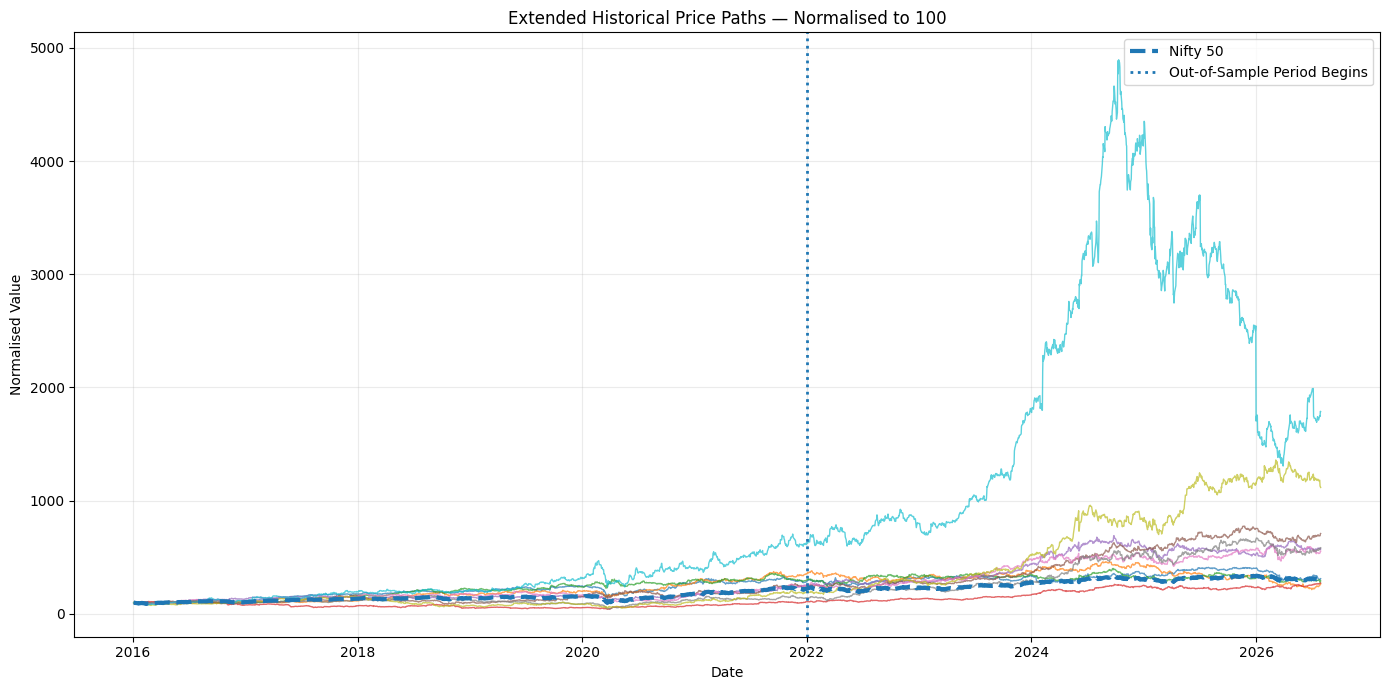

In [6]:
# ---------------------------------------------------------
# Visual validation of the extended dataset
# ---------------------------------------------------------

normalised_prices = (
    close_prices
    .div(close_prices.iloc[0])
    .mul(100)
)

plt.figure(figsize=(14, 7))

for ticker in portfolio_tickers:

    plt.plot(
        normalised_prices.index,
        normalised_prices[ticker],
        linewidth=1,
        alpha=0.70,
    )

plt.plot(
    normalised_prices.index,
    normalised_prices[BENCHMARK_TICKER],
    linewidth=3,
    linestyle="--",
    label=BENCHMARK_NAME,
)

plt.axvline(
    OUT_OF_SAMPLE_START_DATE,
    linewidth=2,
    linestyle=":",
    label="Out-of-Sample Period Begins",
)

plt.title(
    "Extended Historical Price Paths — Normalised to 100"
)
plt.xlabel("Date")
plt.ylabel("Normalised Value")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Reusable Adaptive Barbell Backtesting Engine

A reusable backtesting function is required for robustness testing.

The function accepts alternative strategy parameters, generates month-end signals, delays implementation until the next trading day, deducts transaction costs and returns the complete strategy history.

Using one common engine ensures that every parameter combination is tested consistently.

In [7]:
def run_adaptive_barbell_backtest(
    stock_price_data,
    benchmark_price_data,
    resilient_stock_tickers,
    growth_stock_tickers,
    momentum_lookback=126,
    volatility_lookback=63,
    trend_lookback=200,
    defensive_equity_exposure=0.70,
    transaction_cost_rate=0.0015,
    initial_capital=1_000_000,
    annual_cash_rate=0.065,
    trading_days=252,
):
    """
    Run the Adaptive Barbell strategy using the supplied parameters.

    The strategy:
    - assigns 50% of equity exposure to Resilient Compounders,
    - assigns 50% to Growth Leaders,
    - uses inverse-volatility weights for Resilient Compounders,
    - uses momentum and low-volatility scores for Growth Leaders,
    - reduces equity exposure when the benchmark is below its
      long-term moving average,
    - executes signals on the next trading day, and
    - deducts transaction costs based on one-way turnover.
    """

    # -----------------------------------------------------
    # Input validation
    # -----------------------------------------------------

    stock_price_data = (
        stock_price_data
        .copy()
        .sort_index()
        .astype(float)
    )

    benchmark_price_data = (
        benchmark_price_data
        .copy()
        .sort_index()
        .astype(float)
    )

    all_strategy_tickers = (
        resilient_stock_tickers
        + growth_stock_tickers
    )

    if len(set(all_strategy_tickers)) != len(all_strategy_tickers):
        raise ValueError(
            "A ticker appears in more than one strategy bucket."
        )

    missing_tickers = [
        ticker
        for ticker in all_strategy_tickers
        if ticker not in stock_price_data.columns
    ]

    if missing_tickers:
        raise ValueError(
            "Missing stock-price data for: "
            + ", ".join(missing_tickers)
        )

    if not 0 <= defensive_equity_exposure <= 1:
        raise ValueError(
            "Defensive equity exposure must be between 0 and 1."
        )

    if transaction_cost_rate < 0:
        raise ValueError(
            "Transaction-cost rate cannot be negative."
        )

    # Align stocks and benchmark on common trading dates
    aligned_data = pd.concat(
        [
            stock_price_data[all_strategy_tickers],
            benchmark_price_data.rename("Benchmark"),
        ],
        axis=1,
    ).dropna()

    stock_data = aligned_data[all_strategy_tickers]
    benchmark_data = aligned_data["Benchmark"]

    # -----------------------------------------------------
    # Strategy signals
    # -----------------------------------------------------

    stock_returns = stock_data.pct_change()

    momentum = (
        stock_data
        .div(stock_data.shift(momentum_lookback))
        .sub(1)
    )

    annualised_volatility = (
        stock_returns
        .rolling(
            window=volatility_lookback,
            min_periods=volatility_lookback,
        )
        .std(ddof=1)
        .mul(np.sqrt(trading_days))
    )

    benchmark_moving_average = (
        benchmark_data
        .rolling(
            window=trend_lookback,
            min_periods=trend_lookback,
        )
        .mean()
    )

    month_end_dates = (
        stock_data
        .groupby(stock_data.index.to_period("M"))
        .tail(1)
        .index
    )

    # -----------------------------------------------------
    # Generate month-end target weights
    # -----------------------------------------------------

    target_weight_records = []
    regime_records = []

    for signal_date in month_end_dates:

        resilient_volatility = (
            annualised_volatility
            .loc[signal_date, resilient_stock_tickers]
        )

        growth_volatility = (
            annualised_volatility
            .loc[signal_date, growth_stock_tickers]
        )

        growth_momentum = (
            momentum
            .loc[signal_date, growth_stock_tickers]
        )

        benchmark_level = benchmark_data.loc[
            signal_date
        ]

        benchmark_trend = benchmark_moving_average.loc[
            signal_date
        ]

        required_values = pd.concat(
            [
                resilient_volatility,
                growth_volatility,
                growth_momentum,
                pd.Series(
                    {
                        "Benchmark Level": benchmark_level,
                        "Benchmark Trend": benchmark_trend,
                    }
                ),
            ]
        )

        if required_values.isna().any():
            continue

        # Resilient bucket: inverse-volatility weighting
        resilient_inverse_volatility = (
            1
            / resilient_volatility.replace(
                0,
                np.nan,
            )
        )

        if resilient_inverse_volatility.isna().any():
            continue

        resilient_weights = (
            resilient_inverse_volatility
            / resilient_inverse_volatility.sum()
        )

        # Growth bucket: 70% momentum and 30% low volatility
        momentum_score = growth_momentum.rank(
            pct=True,
            method="average",
            ascending=True,
        )

        low_volatility_score = growth_volatility.rank(
            pct=True,
            method="average",
            ascending=False,
        )

        growth_score = (
            0.70 * momentum_score
            + 0.30 * low_volatility_score
        )

        growth_weights = (
            growth_score
            / growth_score.sum()
        )

        base_equity_weights = pd.Series(
            0.0,
            index=all_strategy_tickers,
            dtype=float,
        )

        base_equity_weights.loc[
            resilient_stock_tickers
        ] = (
            0.50 * resilient_weights
        )

        base_equity_weights.loc[
            growth_stock_tickers
        ] = (
            0.50 * growth_weights
        )

        # Market-regime overlay
        if benchmark_level >= benchmark_trend:
            market_regime = "Normal"
            equity_exposure = 1.0
        else:
            market_regime = "Defensive"
            equity_exposure = (
                defensive_equity_exposure
            )

        final_stock_weights = (
            base_equity_weights
            * equity_exposure
        )

        target_row = final_stock_weights.copy()
        target_row["Cash"] = (
            1.0 - final_stock_weights.sum()
        )
        target_row.name = signal_date

        target_weight_records.append(target_row)

        regime_records.append(
            {
                "Signal Date": signal_date,
                "Market Regime": market_regime,
                "Equity Exposure": equity_exposure,
                "Cash Weight": target_row["Cash"],
                "Benchmark Level": benchmark_level,
                "Benchmark Moving Average": benchmark_trend,
            }
        )

    if not target_weight_records:
        raise ValueError(
            "No valid strategy signals were generated."
        )

    target_weights = (
        pd.DataFrame(target_weight_records)
        .sort_index()
    )

    regime_history = (
        pd.DataFrame(regime_records)
        .set_index("Signal Date")
        .sort_index()
    )

    if not np.allclose(
        target_weights.sum(axis=1),
        1.0,
    ):
        raise ValueError(
            "Generated target weights do not total 100%."
        )

    # -----------------------------------------------------
    # Move each signal to the next trading day
    # -----------------------------------------------------

    execution_records = []
    execution_mapping_records = []

    for signal_date, target_row in target_weights.iterrows():

        next_position = stock_data.index.searchsorted(
            signal_date,
            side="right",
        )

        if next_position >= len(stock_data.index):
            continue

        execution_date = stock_data.index[
            next_position
        ]

        execution_row = target_row.copy()
        execution_row.name = execution_date

        execution_records.append(execution_row)

        execution_mapping_records.append(
            {
                "Signal Date": signal_date,
                "Execution Date": execution_date,
                "Market Regime": regime_history.loc[
                    signal_date,
                    "Market Regime",
                ],
                "Equity Exposure": regime_history.loc[
                    signal_date,
                    "Equity Exposure",
                ],
                "Cash Weight": target_row["Cash"],
            }
        )

    if not execution_records:
        raise ValueError(
            "No executable strategy signals were generated."
        )

    execution_targets = (
        pd.DataFrame(execution_records)
        .groupby(level=0)
        .last()
        .sort_index()
    )

    execution_schedule = (
        pd.DataFrame(execution_mapping_records)
        .drop_duplicates(
            subset="Execution Date",
            keep="last",
        )
        .set_index("Execution Date")
        .sort_index()
    )

    # -----------------------------------------------------
    # Daily portfolio simulation
    # -----------------------------------------------------

    first_execution_date = (
        execution_targets.index.min()
    )

    first_execution_position = (
        stock_data.index.get_loc(
            first_execution_date
        )
    )

    if first_execution_position == 0:
        raise ValueError(
            "No earlier trading date exists to initialise the backtest."
        )

    backtest_initial_date = stock_data.index[
        first_execution_position - 1
    ]

    simulation_dates = stock_data.loc[
        first_execution_date:
    ].index

    asset_names = (
        all_strategy_tickers + ["Cash"]
    )

    current_asset_values = pd.Series(
        0.0,
        index=asset_names,
        dtype=float,
    )

    current_asset_values["Cash"] = float(
        initial_capital
    )

    daily_cash_return = (
        (1 + annual_cash_rate)
        ** (1 / trading_days)
        - 1
    )

    strategy_value_records = {
        backtest_initial_date: float(
            initial_capital
        )
    }

    weight_history_records = {
        backtest_initial_date: (
            current_asset_values
            / float(initial_capital)
        )
    }

    turnover_records = {}
    transaction_cost_records = {}

    for current_date in simulation_dates:

        portfolio_value_before_trade = (
            current_asset_values.sum()
        )

        if current_date in execution_targets.index:

            target_row = (
                execution_targets
                .loc[current_date]
                .reindex(asset_names)
                .astype(float)
            )

            current_weights = (
                current_asset_values
                / portfolio_value_before_trade
            )

            one_way_turnover = (
                0.5
                * (
                    target_row
                    - current_weights
                )
                .abs()
                .sum()
            )

            transaction_cost = (
                portfolio_value_before_trade
                * one_way_turnover
                * transaction_cost_rate
            )

            value_after_cost = (
                portfolio_value_before_trade
                - transaction_cost
            )

            current_asset_values = (
                target_row
                * value_after_cost
            )

            turnover_records[current_date] = (
                one_way_turnover
            )

            transaction_cost_records[current_date] = (
                transaction_cost
            )

        equity_returns_today = (
            stock_returns
            .loc[current_date, all_strategy_tickers]
            .fillna(0.0)
        )

        current_asset_values.loc[
            all_strategy_tickers
        ] *= (
            1 + equity_returns_today
        )

        current_asset_values["Cash"] *= (
            1 + daily_cash_return
        )

        current_portfolio_value = (
            current_asset_values.sum()
        )

        strategy_value_records[current_date] = (
            current_portfolio_value
        )

        weight_history_records[current_date] = (
            current_asset_values
            / current_portfolio_value
        )

    strategy_values = (
        pd.Series(
            strategy_value_records,
            name="Adaptive Barbell Strategy",
        )
        .sort_index()
    )

    weight_history = (
        pd.DataFrame(weight_history_records)
        .T
        .sort_index()
    )

    turnover_history = (
        pd.Series(
            turnover_records,
            name="One-Way Turnover",
            dtype=float,
        )
        .sort_index()
    )

    transaction_cost_history = (
        pd.Series(
            transaction_cost_records,
            name="Transaction Cost",
            dtype=float,
        )
        .sort_index()
    )

    # -----------------------------------------------------
    # Final validation
    # -----------------------------------------------------

    if strategy_values.isna().any():
        raise ValueError(
            "Missing portfolio values were generated."
        )

    if (strategy_values <= 0).any():
        raise ValueError(
            "A non-positive portfolio value was generated."
        )

    if not np.allclose(
        weight_history.sum(axis=1),
        1.0,
    ):
        raise ValueError(
            "Recorded portfolio weights do not total 100%."
        )

    return {
        "Strategy Values": strategy_values,
        "Weight History": weight_history,
        "Turnover": turnover_history,
        "Transaction Costs": transaction_cost_history,
        "Target Weights": target_weights,
        "Regime History": regime_history,
        "Execution Targets": execution_targets,
        "Execution Schedule": execution_schedule,
        "Backtest Initial Date": backtest_initial_date,
        "First Execution Date": first_execution_date,
        "Parameters": {
            "Momentum Lookback": momentum_lookback,
            "Volatility Lookback": volatility_lookback,
            "Trend Lookback": trend_lookback,
            "Defensive Equity Exposure": defensive_equity_exposure,
            "Transaction Cost Rate": transaction_cost_rate,
        },
    }

In [8]:
base_backtest = run_adaptive_barbell_backtest(
    stock_price_data=stock_prices,
    benchmark_price_data=benchmark_prices[BENCHMARK_NAME],
    resilient_stock_tickers=resilient_tickers,
    growth_stock_tickers=growth_tickers,
    momentum_lookback=BASE_MOMENTUM_LOOKBACK,
    volatility_lookback=BASE_VOLATILITY_LOOKBACK,
    trend_lookback=BASE_TREND_LOOKBACK,
    defensive_equity_exposure=BASE_DEFENSIVE_EQUITY_EXPOSURE,
    transaction_cost_rate=TRANSACTION_COST_RATE,
    initial_capital=INITIAL_CAPITAL,
    annual_cash_rate=RISK_FREE_RATE,
    trading_days=TRADING_DAYS,
)

base_strategy_values = base_backtest[
    "Strategy Values"
]

print("Reusable base-strategy backtest completed.")
print("-" * 55)
print(
    "Backtest initial date:",
    base_backtest["Backtest Initial Date"].date(),
)
print(
    "First execution date:",
    base_backtest["First Execution Date"].date(),
)
print(
    "Latest strategy value:",
    f"₹{base_strategy_values.iloc[-1]:,.0f}",
)
print(
    "Number of rebalances:",
    len(base_backtest["Turnover"]),
)
print(
    "Average turnover:",
    f"{base_backtest['Turnover'].mean():.2%}",
)
print(
    "Total transaction costs:",
    f"₹{base_backtest['Transaction Costs'].sum():,.0f}",
)

Reusable base-strategy backtest completed.
-------------------------------------------------------
Backtest initial date: 2016-10-28
First execution date: 2016-11-01
Latest strategy value: ₹5,954,167
Number of rebalances: 117
Average turnover: 11.35%
Total transaction costs: ₹50,055


## 5. Development and Out-of-Sample Evaluation

The frozen Adaptive Barbell strategy is evaluated separately across:

- **Development period:** observations before 1 January 2022
- **Out-of-sample period:** observations from 1 January 2022 onward

Each strategy, fixed portfolio and benchmark series is rebased to ₹10 lakh at the beginning of the relevant period so that performance is directly comparable.

In [9]:
# ---------------------------------------------------------
# Create fixed-portfolio and benchmark comparisons
# ---------------------------------------------------------

base_initial_date = base_backtest[
    "Backtest Initial Date"
]

comparison_stock_prices = (
    stock_prices
    .loc[base_initial_date:]
    .copy()
)

initial_stock_prices = (
    comparison_stock_prices
    .iloc[0]
)

equal_weights = (
    portfolio
    .set_index("Ticker")["Initial Weight"]
    .reindex(portfolio_tickers)
)

fixed_allocations = (
    equal_weights * INITIAL_CAPITAL
)

fixed_shares = (
    fixed_allocations
    / initial_stock_prices
)

fixed_portfolio_values = (
    comparison_stock_prices
    .mul(fixed_shares, axis=1)
    .sum(axis=1)
    .rename("Fixed India 10 Portfolio")
)

comparison_benchmark = (
    benchmark_prices[BENCHMARK_NAME]
    .loc[base_initial_date:]
)

benchmark_units = (
    INITIAL_CAPITAL
    / comparison_benchmark.iloc[0]
)

benchmark_values = (
    comparison_benchmark
    * benchmark_units
)

benchmark_values.name = BENCHMARK_NAME

full_comparison_values = pd.concat(
    [
        base_strategy_values,
        fixed_portfolio_values,
        benchmark_values,
    ],
    axis=1,
).dropna()

assert not full_comparison_values.empty
assert full_comparison_values.isna().sum().sum() == 0

print("Comparable full-period series created.")
print("-" * 55)
print(
    f"Evaluation begins: "
    f"{full_comparison_values.index.min().date()}"
)
print(
    f"Evaluation ends: "
    f"{full_comparison_values.index.max().date()}"
)
print(
    f"Trading observations: "
    f"{len(full_comparison_values):,}"
)

display(full_comparison_values.tail())

Comparable full-period series created.
-------------------------------------------------------
Evaluation begins: 2016-10-28
Evaluation ends: 2026-07-30
Trading observations: 2,413


,Adaptive Barbell Strategy,Fixed India 10 Portfolio,Nifty 50
2026-07-24,"5,900,462.3319","5,908,843.4104","2,751,499.0992"
2026-07-27,"5,936,862.1842","5,970,770.6913","2,777,951.9818"
2026-07-28,"5,889,764.5985","5,902,301.2443","2,776,724.8911"
2026-07-29,"5,943,677.4553","5,978,190.2172","2,807,385.8785"
2026-07-30,"5,954,167.0780","5,985,914.6634","2,815,136.6509"


In [10]:
def calculate_period_metrics(
    value_series,
    benchmark_return_series,
    annual_risk_free_rate=0.065,
    trading_days=252,
):
    """
    Calculate return, risk and benchmark-relative metrics
    for one evaluation period.
    """

    value_series = (
        value_series
        .dropna()
        .astype(float)
    )

    if len(value_series) < 2:
        raise ValueError(
            "At least two observations are required."
        )

    return_series = (
        value_series
        .pct_change()
        .dropna()
    )

    aligned_returns = pd.concat(
        [
            return_series.rename("Asset"),
            benchmark_return_series.rename("Benchmark"),
        ],
        axis=1,
    ).dropna()

    years = (
        value_series.index[-1]
        - value_series.index[0]
    ).days / 365.25

    if years <= 0:
        raise ValueError(
            "Evaluation period must exceed zero years."
        )

    total_return = (
        value_series.iloc[-1]
        / value_series.iloc[0]
        - 1
    )

    cagr = (
        value_series.iloc[-1]
        / value_series.iloc[0]
    ) ** (1 / years) - 1

    annualised_volatility = (
        return_series.std(ddof=1)
        * np.sqrt(trading_days)
    )

    daily_risk_free_rate = (
        (1 + annual_risk_free_rate)
        ** (1 / trading_days)
        - 1
    )

    excess_returns = (
        return_series
        - daily_risk_free_rate
    )

    annualised_excess_return = (
        excess_returns.mean()
        * trading_days
    )

    sharpe_ratio = (
        annualised_excess_return
        / annualised_volatility
        if annualised_volatility > 0
        else np.nan
    )

    downside_returns = (
        excess_returns
        .clip(upper=0)
    )

    downside_deviation = (
        np.sqrt(
            np.mean(downside_returns ** 2)
        )
        * np.sqrt(trading_days)
    )

    sortino_ratio = (
        annualised_excess_return
        / downside_deviation
        if downside_deviation > 0
        else np.nan
    )

    drawdown = (
        value_series
        / value_series.cummax()
        - 1
    )

    maximum_drawdown = drawdown.min()

    calmar_ratio = (
        cagr / abs(maximum_drawdown)
        if maximum_drawdown < 0
        else np.nan
    )

    benchmark_variance = (
        aligned_returns["Benchmark"]
        .var(ddof=1)
    )

    beta = (
        aligned_returns
        .cov()
        .loc["Asset", "Benchmark"]
        / benchmark_variance
        if benchmark_variance > 0
        else np.nan
    )

    correlation = (
        aligned_returns["Asset"]
        .corr(aligned_returns["Benchmark"])
    )

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annualised Volatility": annualised_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Sortino Ratio": sortino_ratio,
        "Maximum Drawdown": maximum_drawdown,
        "Calmar Ratio": calmar_ratio,
        "Beta vs Nifty 50": beta,
        "Correlation vs Nifty 50": correlation,
    }

In [11]:
def evaluate_period(
    comparison_data,
    period_start=None,
    period_end=None,
    initial_value=1_000_000,
):
    """
    Slice a period, rebase each investment to the same starting
    value and calculate comparable performance metrics.
    """

    period_values = comparison_data.copy()

    if period_start is not None:
        period_values = period_values.loc[
            period_values.index >= pd.Timestamp(period_start)
        ]

    if period_end is not None:
        period_values = period_values.loc[
            period_values.index <= pd.Timestamp(period_end)
        ]

    period_values = period_values.dropna()

    if len(period_values) < 2:
        raise ValueError(
            "The selected period contains insufficient observations."
        )

    rebased_values = (
        period_values
        .div(period_values.iloc[0])
        .mul(initial_value)
    )

    period_returns = (
        rebased_values
        .pct_change()
        .dropna()
    )

    benchmark_returns = (
        period_returns[BENCHMARK_NAME]
    )

    metric_results = {}

    for investment_name in rebased_values.columns:

        metric_results[investment_name] = (
            calculate_period_metrics(
                value_series=rebased_values[
                    investment_name
                ],
                benchmark_return_series=benchmark_returns,
                annual_risk_free_rate=RISK_FREE_RATE,
                trading_days=TRADING_DAYS,
            )
        )

    metrics_table = pd.DataFrame(
        metric_results
    )

    return {
        "Values": rebased_values,
        "Metrics": metrics_table,
        "Start Date": rebased_values.index.min(),
        "End Date": rebased_values.index.max(),
    }

In [12]:
development_end_date = (
    OUT_OF_SAMPLE_START_DATE
    - pd.Timedelta(days=1)
)

development_evaluation = evaluate_period(
    comparison_data=full_comparison_values,
    period_start=base_initial_date,
    period_end=development_end_date,
    initial_value=INITIAL_CAPITAL,
)

out_of_sample_evaluation = evaluate_period(
    comparison_data=full_comparison_values,
    period_start=OUT_OF_SAMPLE_START_DATE,
    period_end=None,
    initial_value=INITIAL_CAPITAL,
)

development_metrics = (
    development_evaluation["Metrics"]
)

out_of_sample_metrics = (
    out_of_sample_evaluation["Metrics"]
)

print("Development period")
print(
    development_evaluation["Start Date"].date(),
    "to",
    development_evaluation["End Date"].date(),
)

print("\nOut-of-sample period")
print(
    out_of_sample_evaluation["Start Date"].date(),
    "to",
    out_of_sample_evaluation["End Date"].date(),
)

Development period
2016-10-28 to 2021-12-31

Out-of-sample period
2022-01-03 to 2026-07-30


In [13]:
def format_metrics_table(metrics_table):

    selected_metrics = metrics_table.loc[
        [
            "Total Return",
            "CAGR",
            "Annualised Volatility",
            "Sharpe Ratio",
            "Sortino Ratio",
            "Maximum Drawdown",
            "Calmar Ratio",
            "Beta vs Nifty 50",
            "Correlation vs Nifty 50",
        ]
    ].copy()

    formatted_table = (
        selected_metrics
        .copy()
        .astype(object)
    )

    percentage_metrics = [
        "Total Return",
        "CAGR",
        "Annualised Volatility",
        "Maximum Drawdown",
    ]

    ratio_metrics = [
        "Sharpe Ratio",
        "Sortino Ratio",
        "Calmar Ratio",
        "Beta vs Nifty 50",
        "Correlation vs Nifty 50",
    ]

    for column in formatted_table.columns:

        for metric in percentage_metrics:
            formatted_table.loc[
                metric,
                column,
            ] = (
                f"{selected_metrics.loc[metric, column]:.2%}"
            )

        for metric in ratio_metrics:
            formatted_table.loc[
                metric,
                column,
            ] = (
                f"{selected_metrics.loc[metric, column]:.2f}"
            )

    return formatted_table


print("Development-Period Performance")
display(
    format_metrics_table(
        development_metrics
    )
)

print("Out-of-Sample Performance")
display(
    format_metrics_table(
        out_of_sample_metrics
    )
)

Development-Period Performance


,Adaptive Barbell Strategy,Fixed India 10 Portfolio,Nifty 50
Total Return,153.62%,153.54%,100.90%
CAGR,19.70%,19.70%,14.43%
Annualised Volatility,14.90%,17.31%,18.20%
Sharpe Ratio,0.88,0.78,0.50
Sortino Ratio,1.24,1.10,0.68
Maximum Drawdown,-23.73%,-32.06%,-38.44%
Calmar Ratio,0.83,0.61,0.38
Beta vs Nifty 50,0.69,0.83,1.00
Correlation vs Nifty 50,0.84,0.87,1.00


Out-of-Sample Performance


,Adaptive Barbell Strategy,Fixed India 10 Portfolio,Nifty 50
Total Return,132.79%,134.65%,37.96%
CAGR,20.31%,20.52%,7.30%
Annualised Volatility,12.91%,18.92%,13.84%
Sharpe Ratio,1.03,0.77,0.13
Sortino Ratio,1.50,1.06,0.18
Maximum Drawdown,-14.79%,-35.86%,-16.47%
Calmar Ratio,1.37,0.57,0.44
Beta vs Nifty 50,0.81,1.00,1.00
Correlation vs Nifty 50,0.87,0.73,1.00


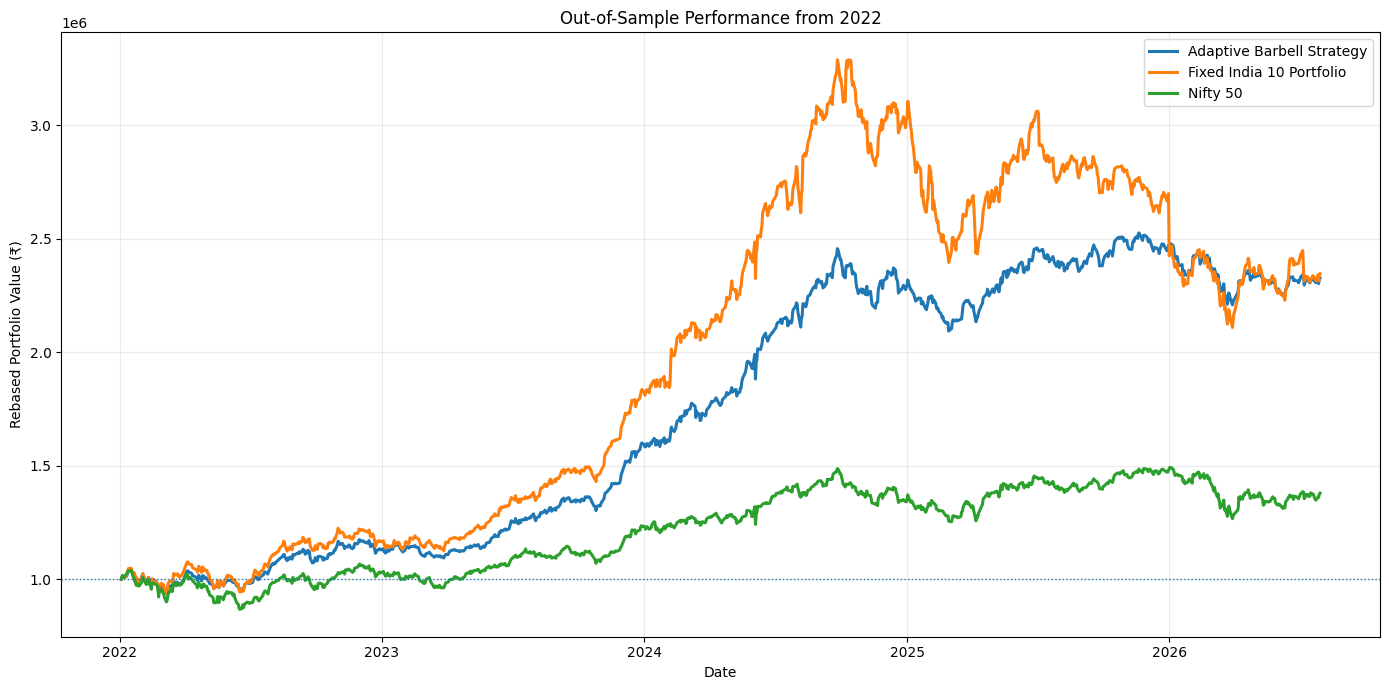

In [14]:
out_of_sample_values = (
    out_of_sample_evaluation["Values"]
)

plt.figure(figsize=(14, 7))

for column in out_of_sample_values.columns:

    plt.plot(
        out_of_sample_values.index,
        out_of_sample_values[column],
        linewidth=2.2,
        label=column,
    )

plt.axhline(
    INITIAL_CAPITAL,
    linewidth=1,
    linestyle=":",
)

plt.title(
    "Out-of-Sample Performance from 2022"
)
plt.xlabel("Date")
plt.ylabel("Rebased Portfolio Value (₹)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Development and Out-of-Sample Interpretation

### Development-period result

During the development period, the Adaptive Barbell strategy generated a CAGR of 19.70%, equal to the fixed portfolio's CAGR.

However, the Adaptive strategy reduced annualised volatility from 17.31% to 14.90% and improved maximum drawdown from -32.06% to -23.73%.

Its Sharpe, Sortino and Calmar ratios were also higher, indicating improved risk-adjusted performance.

### Out-of-sample result

From 2022 onward, the Adaptive strategy generated a CAGR of 20.31%, compared with 20.52% for the fixed India 10 portfolio.

The strategy therefore sacrificed only 0.21 percentage points of annual return while producing substantially lower risk.

Annualised volatility declined from 18.92% to 12.91%, while maximum drawdown improved from -35.86% to -14.79%.

The Adaptive strategy also generated:

- a Sharpe ratio of 1.03 versus 0.77,
- a Sortino ratio of 1.50 versus 1.06,
- a Calmar ratio of 1.37 versus 0.57, and
- a beta of 0.81 versus 1.00.

### Preliminary robustness conclusion

The strategy's risk-adjusted advantage persisted during the out-of-sample period.

The strongest evidence relates to downside protection rather than absolute-return enhancement. The strategy maintained nearly the same CAGR as the fixed portfolio while materially reducing volatility, market sensitivity and maximum drawdown.

The strategy is therefore provisionally classified as **moderately robust**, subject to parameter-sensitivity and transaction-cost stress testing.

### Important limitation

The test is out-of-sample with respect to time and the frozen strategy parameters. It is not completely free from selection bias because the current ten-stock portfolio was chosen using present-day information.

## 7. Parameter-Sensitivity Testing

The strategy is tested across reasonable alternative values for:

- momentum lookback,
- volatility lookback,
- market-trend lookback, and
- defensive equity exposure.

The objective is not to discover the historically best combination. A robust strategy should perform reasonably across many nearby parameter combinations rather than depending on one exact setting.

In [15]:
# ---------------------------------------------------------
# Parameter grid
# ---------------------------------------------------------

momentum_lookbacks = [63, 126, 252]
volatility_lookbacks = [21, 63, 126]
trend_lookbacks = [100, 150, 200]
defensive_exposures = [0.50, 0.70, 0.80]

parameter_combinations = list(
    product(
        momentum_lookbacks,
        volatility_lookbacks,
        trend_lookbacks,
        defensive_exposures,
    )
)

print(f"Parameter combinations to test: {len(parameter_combinations)}")

Parameter combinations to test: 81


In [16]:
# ---------------------------------------------------------
# Run every parameter combination
# ---------------------------------------------------------

sensitivity_records = []
failed_combinations = []

for combination_number, (
    momentum_window,
    volatility_window,
    trend_window,
    defensive_exposure,
) in enumerate(parameter_combinations, start=1):

    try:
        test_backtest = run_adaptive_barbell_backtest(
            stock_price_data=stock_prices,
            benchmark_price_data=benchmark_prices[BENCHMARK_NAME],
            resilient_stock_tickers=resilient_tickers,
            growth_stock_tickers=growth_tickers,
            momentum_lookback=momentum_window,
            volatility_lookback=volatility_window,
            trend_lookback=trend_window,
            defensive_equity_exposure=defensive_exposure,
            transaction_cost_rate=TRANSACTION_COST_RATE,
            initial_capital=INITIAL_CAPITAL,
            annual_cash_rate=RISK_FREE_RATE,
            trading_days=TRADING_DAYS,
        )

        strategy_values = (
            test_backtest["Strategy Values"]
            .loc[
                test_backtest["Strategy Values"].index
                >= OUT_OF_SAMPLE_START_DATE
            ]
            .dropna()
        )

        benchmark_period_prices = (
            benchmark_prices[BENCHMARK_NAME]
            .reindex(strategy_values.index)
            .dropna()
        )

        strategy_values = strategy_values.reindex(
            benchmark_period_prices.index
        )

        benchmark_period_returns = (
            benchmark_period_prices
            .pct_change()
            .dropna()
        )

        strategy_metrics = calculate_period_metrics(
            value_series=strategy_values,
            benchmark_return_series=benchmark_period_returns,
            annual_risk_free_rate=RISK_FREE_RATE,
            trading_days=TRADING_DAYS,
        )

        sensitivity_records.append(
            {
                "Momentum Lookback": momentum_window,
                "Volatility Lookback": volatility_window,
                "Trend Lookback": trend_window,
                "Defensive Exposure": defensive_exposure,
                "CAGR": strategy_metrics["CAGR"],
                "Annualised Volatility": strategy_metrics[
                    "Annualised Volatility"
                ],
                "Sharpe Ratio": strategy_metrics["Sharpe Ratio"],
                "Sortino Ratio": strategy_metrics["Sortino Ratio"],
                "Maximum Drawdown": strategy_metrics[
                    "Maximum Drawdown"
                ],
                "Calmar Ratio": strategy_metrics["Calmar Ratio"],
                "Beta vs Nifty 50": strategy_metrics[
                    "Beta vs Nifty 50"
                ],
                "Average Turnover": test_backtest[
                    "Turnover"
                ].mean(),
                "Total Transaction Costs": test_backtest[
                    "Transaction Costs"
                ].sum(),
            }
        )

    except Exception as error:
        failed_combinations.append(
            {
                "Momentum Lookback": momentum_window,
                "Volatility Lookback": volatility_window,
                "Trend Lookback": trend_window,
                "Defensive Exposure": defensive_exposure,
                "Error": str(error),
            }
        )

    if combination_number % 10 == 0:
        print(
            f"Completed {combination_number} "
            f"of {len(parameter_combinations)} combinations."
        )


sensitivity_results = pd.DataFrame(
    sensitivity_records
)

failed_sensitivity_tests = pd.DataFrame(
    failed_combinations
)

assert not sensitivity_results.empty, \
    "No sensitivity-test results were generated."

print("\nParameter-sensitivity testing completed.")
print("-" * 60)
print(f"Successful tests: {len(sensitivity_results)}")
print(f"Failed tests: {len(failed_sensitivity_tests)}")

Completed 10 of 81 combinations.
Completed 20 of 81 combinations.
Completed 30 of 81 combinations.
Completed 40 of 81 combinations.
Completed 50 of 81 combinations.
Completed 60 of 81 combinations.
Completed 70 of 81 combinations.
Completed 80 of 81 combinations.

Parameter-sensitivity testing completed.
------------------------------------------------------------
Successful tests: 81
Failed tests: 0


In [17]:
# ---------------------------------------------------------
# Compare parameter combinations with the fixed portfolio
# ---------------------------------------------------------

fixed_oos_cagr = out_of_sample_metrics.loc[
    "CAGR",
    "Fixed India 10 Portfolio",
]

fixed_oos_sharpe = out_of_sample_metrics.loc[
    "Sharpe Ratio",
    "Fixed India 10 Portfolio",
]

fixed_oos_drawdown = out_of_sample_metrics.loc[
    "Maximum Drawdown",
    "Fixed India 10 Portfolio",
]

sensitivity_results["CAGR Difference vs Fixed"] = (
    sensitivity_results["CAGR"]
    - fixed_oos_cagr
)

sensitivity_results["Sharpe Difference vs Fixed"] = (
    sensitivity_results["Sharpe Ratio"]
    - fixed_oos_sharpe
)

sensitivity_results["Drawdown Improvement vs Fixed"] = (
    sensitivity_results["Maximum Drawdown"]
    - fixed_oos_drawdown
)

robustness_summary = pd.Series(
    {
        "Median CAGR": sensitivity_results["CAGR"].median(),
        "Minimum CAGR": sensitivity_results["CAGR"].min(),
        "Maximum CAGR": sensitivity_results["CAGR"].max(),
        "Median Volatility": sensitivity_results[
            "Annualised Volatility"
        ].median(),
        "Median Sharpe Ratio": sensitivity_results[
            "Sharpe Ratio"
        ].median(),
        "Minimum Sharpe Ratio": sensitivity_results[
            "Sharpe Ratio"
        ].min(),
        "Median Maximum Drawdown": sensitivity_results[
            "Maximum Drawdown"
        ].median(),
        "Combinations Beating Fixed Sharpe": (
            sensitivity_results["Sharpe Ratio"]
            > fixed_oos_sharpe
        ).mean(),
        "Combinations Improving Fixed Drawdown": (
            sensitivity_results["Maximum Drawdown"]
            > fixed_oos_drawdown
        ).mean(),
        "Combinations Within 2% CAGR of Fixed": (
            sensitivity_results["CAGR Difference vs Fixed"]
            >= -0.02
        ).mean(),
    }
)

display(
    robustness_summary.to_frame("Result").style.format(
        {
            "Result": "{:.2%}",
        }
    )
)

,Result
Median CAGR,20.03%
Minimum CAGR,19.33%
Maximum CAGR,20.68%
Median Volatility,12.83%
Median Sharpe Ratio,103.27%
Minimum Sharpe Ratio,95.61%
Median Maximum Drawdown,-14.80%
Combinations Beating Fixed Sharpe,100.00%
Combinations Improving Fixed Drawdown,100.00%
Combinations Within 2% CAGR of Fixed,100.00%


In [18]:
# Correctly format percentages and ratios separately

corrected_robustness_summary = pd.DataFrame(
    {
        "Metric": [
            "Median CAGR",
            "Minimum CAGR",
            "Maximum CAGR",
            "Median Volatility",
            "Median Sharpe Ratio",
            "Minimum Sharpe Ratio",
            "Median Maximum Drawdown",
            "Combinations Beating Fixed Sharpe",
            "Combinations Improving Fixed Drawdown",
            "Combinations Within 2% CAGR of Fixed",
        ],
        "Result": [
            f"{sensitivity_results['CAGR'].median():.2%}",
            f"{sensitivity_results['CAGR'].min():.2%}",
            f"{sensitivity_results['CAGR'].max():.2%}",
            f"{sensitivity_results['Annualised Volatility'].median():.2%}",
            f"{sensitivity_results['Sharpe Ratio'].median():.2f}",
            f"{sensitivity_results['Sharpe Ratio'].min():.2f}",
            f"{sensitivity_results['Maximum Drawdown'].median():.2%}",
            f"{(sensitivity_results['Sharpe Ratio'] > fixed_oos_sharpe).mean():.2%}",
            f"{(sensitivity_results['Maximum Drawdown'] > fixed_oos_drawdown).mean():.2%}",
            f"{(sensitivity_results['CAGR Difference vs Fixed'] >= -0.02).mean():.2%}",
        ],
    }
).set_index("Metric")

print("Corrected Parameter-Sensitivity Summary")
display(corrected_robustness_summary)

Corrected Parameter-Sensitivity Summary


,Result
Metric,
Median CAGR,20.03%
Minimum CAGR,19.33%
Maximum CAGR,20.68%
Median Volatility,12.83%
Median Sharpe Ratio,1.03
Minimum Sharpe Ratio,0.96
Median Maximum Drawdown,-14.80%
Combinations Beating Fixed Sharpe,100.00%
Combinations Improving Fixed Drawdown,100.00%


## 8. Parameter-Sensitivity Interpretation

A total of 81 alternative parameter combinations were evaluated during the out-of-sample period.

The tested combinations varied:

- momentum lookback,
- volatility lookback,
- market-trend lookback, and
- defensive equity exposure.

### Stability of returns

The median CAGR across all combinations was 20.03%.

The minimum CAGR was 19.33% and the maximum CAGR was 20.68%, representing a relatively narrow performance range.

All tested combinations remained within two percentage points of the fixed portfolio's CAGR.

### Stability of risk-adjusted performance

The median Sharpe ratio was 1.03, while the weakest tested Sharpe ratio was approximately 0.96.

Every tested parameter combination produced a higher Sharpe ratio than the fixed India 10 portfolio.

### Stability of downside protection

The median maximum drawdown was -14.80%.

Every tested parameter combination produced a smaller maximum drawdown than the fixed portfolio.

### Preliminary parameter-robustness conclusion

The strategy does not appear to depend on one precise combination of momentum, volatility, trend or defensive-exposure assumptions.

Reasonable variations in the parameters produced similar returns, consistently stronger risk-adjusted performance and materially improved downside protection.

The strategy is therefore classified as **robust across the tested parameter grid**.

However, this conclusion applies to the strategy parameters only. The portfolio's fixed ten-stock universe remains subject to selection and survivorship bias.